In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, gc
import cv2
import numpy as np
import xml.etree.ElementTree as ET
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
DATASET_DIR    = "/content/drive/MyDrive/Datasets/FaceMaskDetection"
ANNOTATION_DIR = os.path.join(DATASET_DIR, "annotations")
IMAGE_DIR      = os.path.join(DATASET_DIR, "images")
IMG_SIZE       = 224

data, labels = [], []

for xml_file in tqdm(os.listdir(ANNOTATION_DIR)):
    tree = ET.parse(os.path.join(ANNOTATION_DIR, xml_file))
    root = tree.getroot()
    image_path = os.path.join(IMAGE_DIR, root.find("filename").text)
    if not os.path.exists(image_path):
        continue
    image = cv2.imread(image_path)
    if image is None:
        continue
    for obj in root.findall("object"):
        label = obj.find("name").text
        b = obj.find("bndbox")
        xmin, ymin = int(b.find("xmin").text), int(b.find("ymin").text)
        xmax, ymax = int(b.find("xmax").text), int(b.find("ymax").text)
        face = image[ymin:ymax, xmin:xmax]
        if face.size == 0:
            continue
        face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
        data.append(face.astype("uint8"))            # raw uint8, no preprocessing yet
        labels.append(1 if label == "with_mask" else 0)

data   = np.array(data, dtype="uint8")               # ~0.6 GB instead of ~2.3 GB
labels = to_categorical(np.array(labels), num_classes=2)
print("Images:", data.shape, "| Labels:", labels.shape)

100%|██████████| 853/853 [18:27<00:00,  1.30s/it]


Images: (4072, 224, 224, 3) | Labels: (4072, 2)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.20, random_state=42, stratify=labels
)
del data, labels
gc.collect()
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (3257, 224, 224, 3) | Test: (815, 224, 224, 3)


In [ ]:
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE

def make_ds(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(1024)
    ds = ds.batch(BATCH_SIZE)
    # cast uint8 -> float32 and apply MobileNetV2 preprocessing per batch only
    ds = ds.map(lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y),
                num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = make_ds(X_train, y_train, training=True)
test_ds  = make_ds(X_test,  y_test)   # not shuffled -> label order preserved

In [ ]:
baseModel = MobileNetV2(weights="imagenet", include_top=False,
                        input_shape=(224, 224, 3))
baseModel.trainable = False          # freeze pretrained backbone

headModel = baseModel.output
headModel = AveragePooling2D(pool_size=(7, 7))(headModel)
headModel = Flatten()(headModel)
headModel = Dense(128, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(2, activation="softmax")(headModel)

model = Model(inputs=baseModel.input, outputs=headModel)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
INIT_LR = 1e-4
EPOCHS  = 10

model.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=INIT_LR),
    metrics=["accuracy"]
)

history = model.fit(train_ds, validation_data=test_ds, epochs=EPOCHS)

Epoch 1/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 54s 331ms/step - accuracy: 0.7753 - loss: 0.5143 - val_accuracy: 0.8847 - val_loss: 0.2965
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8634 - loss: 0.3223 - val_accuracy: 0.9018 - val_loss: 0.2493
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.8858 - loss: 0.2807 - val_accuracy: 0.9006 - val_loss: 0.2292
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9005 - loss: 0.2564 - val_accuracy: 0.9080 - val_loss: 0.2185
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.9131 - loss: 0.2183 - val_accuracy: 0.9178 - val_loss: 0.2061
Epoch 6/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9153 - loss: 0.2171 - val_accuracy: 0.9178 - val_loss: 0.1995
Epoch 7/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9229 - loss: 0.1979 - val_accuracy: 0.9301 - val_loss: 0.1889
Epoch 8/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9248 - loss: 0.1946 - val_ac

In [ ]:
pred_probs  = model.predict(test_ds)
preds       = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("Accuracy :", accuracy_score(true_labels, preds))
print("Precision:", precision_score(true_labels, preds))
print("Recall   :", recall_score(true_labels, preds))
print(classification_report(true_labels, preds,
                            target_names=["Without Mask", "With Mask"]))

26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step
Accuracy : 0.9300613496932515
Precision: 0.9376854599406528
Recall   : 0.9768160741885626
              precision    recall  f1-score   support

Without Mask       0.89      0.75      0.82       168
   With Mask       0.94      0.98      0.96       647

    accuracy                           0.93       815
   macro avg       0.92      0.86      0.89       815
weighted avg       0.93      0.93      0.93       815



In [ ]:
model.save("face_mask_detector.h5")
print("Saved to face_mask_detector.h5")

Saved to face_mask_detector.h5


In [ ]:
!wget -q https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt -O deploy.prototxt
!wget -q https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel -O res10_300x300_ssd_iter_140000.caffemodel

import os
print("prototxt  bytes:", os.path.getsize("deploy.prototxt"))
print("caffemodel bytes:", os.path.getsize("res10_300x300_ssd_iter_140000.caffemodel"))

faceNet = cv2.dnn.readNet("res10_300x300_ssd_iter_140000.caffemodel", "deploy.prototxt")
maskNet = tf.keras.models.load_model("face_mask_detector.h5")
print("Detector + mask model ready.")

prototxt  bytes: 28104
caffemodel bytes: 10666211


Detector + mask model ready.


In [ ]:
def detect_and_predict(frame, conf_thresh=0.5):
    (h, w) = frame.shape[:2]
    blob = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), (104.0, 177.0, 123.0))
    faceNet.setInput(blob)
    detections = faceNet.forward()

    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence < conf_thresh:
            continue

        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        (startX, startY, endX, endY) = box.astype("int")
        startX, startY = max(0, startX), max(0, startY)
        endX, endY     = min(w - 1, endX), min(h - 1, endY)

        face = frame[startY:endY, startX:endX]
        if face.size == 0:
            continue

        face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
        face = cv2.resize(face, (224, 224))
        face = preprocess_input(face.astype("float32"))
        face = np.expand_dims(face, axis=0)

        (withoutMask, mask) = maskNet.predict(face, verbose=0)[0]
        label = "Mask" if mask > withoutMask else "No Mask"
        color = (0, 255, 0) if label == "Mask" else (0, 0, 255)
        label = f"{label}: {max(mask, withoutMask) * 100:.1f}%"

        cv2.putText(frame, label, (startX, startY - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        cv2.rectangle(frame, (startX, startY), (endX, endY), color, 2)
    return frame

In [ ]:
from google.colab.patches import cv2_imshow

image_path = "/content/test.jpg"      # upload a test image to /content first
frame = cv2.imread(image_path)
if frame is not None:
    cv2_imshow(detect_and_predict(frame))
else:
    print("Upload a test image to /content/test.jpg first.")

Upload a test image to /content/test.jpg first.


<IPython.core.display.Javascript object>

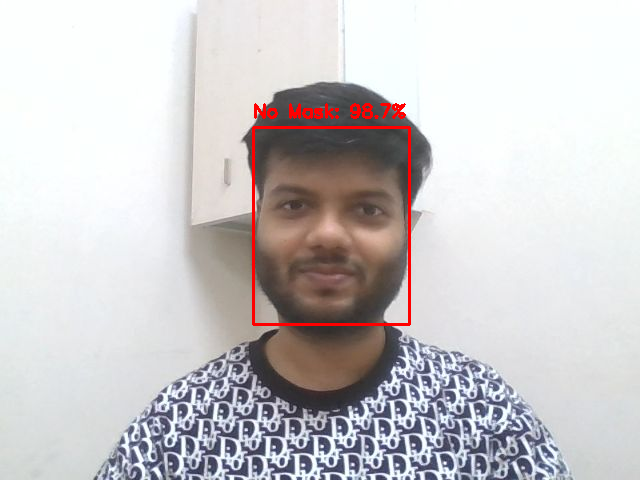

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);
            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();
            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
            await new Promise((resolve) => capture.onclick = resolve);
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
        ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    with open(filename, 'wb') as f:
        f.write(b64decode(data.split(',')[1]))
    return filename

from google.colab.patches import cv2_imshow
photo = take_photo()
frame = cv2.imread(photo)
cv2_imshow(detect_and_predict(frame))